# FEA Prediction Trajectories: Integrated Analysis

Integrated analysis of the frozen ordered FEA LSTM on prefixes of 1–30 observations.

This notebook combines the analyses from the previous **FEA prediction trajectories** and **FEA class probability views** notebooks with the combined class-wise plots for:

1. recall / overall accuracy, and
2. mean true-class probability / overall mean.

All analyses are descriptive prefix probes of the same frozen model. Short prefixes were not separately trained, and the prefix positions are **not** interpreted as onset, apex, or offset phases.

## 1. Setup and input validation

Expected inputs next to this notebook:

- `fea_prediction_trajectories.csv` — required.

All generated files are written to `outputs/`.

In [1]:
from pathlib import Path
import base64
import hashlib
import html
import json
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter


INPUT_PATH = Path('fea_prediction_trajectories.csv')

OUTPUT_DIR = Path('outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

for folder in [FIG_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CLASSES = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
PROB_COLS = [f'probability_{name.lower()}' for name in CLASSES]
COLORS = ['#A8443F', '#8B6B21', '#8757A5', '#CE8615', '#52768D', '#3366A3', '#278778']
STEPS = np.arange(1, 31)
N_SEQUENCES = 378
SEQUENCE_LENGTH = 30

# Used by the detailed all-output probability plots later in the notebook.
SHOW_INDIVIDUALS = True

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.17,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

FIGURES = []

def finish_figure(fig, filename, aliases=None, show=True):
    names = [filename] + ([] if aliases is None else list(aliases))
    for name in names:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=180, bbox_inches='tight')
        fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
        if name not in FIGURES:
            FIGURES.append(name)
    if show:
        plt.show()
    plt.close(fig)

print('Input:', INPUT_PATH.resolve())
print('Output directory:', OUTPUT_DIR.resolve())

Input: /workspace/repos/emohevrdb-dfer/5_dynamic_facial_expression_recognition/5_2_fea_sequence_based_fer/5_2_4_sequence_order_ablation/trajectories/fea_prediction_trajectories.csv
Output directory: /workspace/repos/emohevrdb-dfer/5_dynamic_facial_expression_recognition/5_2_fea_sequence_based_fer/5_2_4_sequence_order_ablation/trajectories/outputs


In [2]:
df = pd.read_csv(INPUT_PATH)

required = {
    'sample_id',
    'sequence_id',
    'sequence_timestamp',
    'participant_id',
    'timestep',
    'observation_timestamp',
    'true_class_id',
    'true_class',
    'predicted_class_id',
    'predicted_class',
    'true_class_probability',
    'predicted_class_probability',
    'correct_at_timestep',
    'correct_final_prediction',
    *PROB_COLS,
}

assert required.issubset(df.columns), sorted(required - set(df.columns))
assert len(df) == N_SEQUENCES * SEQUENCE_LENGTH
assert df['sample_id'].is_unique
assert not df.duplicated(['sequence_id', 'timestep']).any()
assert not df[list(required)].isna().any().any()

for col in ['correct_at_timestep', 'correct_final_prediction']:
    if df[col].dtype != bool:
        df[col] = (
            df[col].astype(str).str.lower()
            .map({'true': True, 'false': False})
        )
        assert df[col].notna().all(), f'Invalid boolean values in {col}'

df = df.sort_values(['sequence_id', 'timestep']).reset_index(drop=True)
groups = df.groupby('sequence_id', sort=True)

assert groups.size().eq(SEQUENCE_LENGTH).all()
assert groups.ngroups == N_SEQUENCES
assert all(np.array_equal(g['timestep'].to_numpy(), STEPS) for _, g in groups)

stable_metadata_columns = [
    'sequence_timestamp',
    'set_id',
    'participant_id',
    'level_id',
    'emoji_id',
    'true_class_id',
    'true_class',
    'correct_final_prediction',
]
for col in stable_metadata_columns:
    if col in df.columns:
        assert groups[col].nunique().eq(1).all(), f'{col} changes within a sequence'

assert df['true_class_id'].isin(range(7)).all()
assert df['predicted_class_id'].isin(range(7)).all()
assert df['true_class'].eq(df['true_class_id'].map(dict(enumerate(CLASSES)))).all()
assert df['predicted_class'].eq(df['predicted_class_id'].map(dict(enumerate(CLASSES)))).all()

# Timestamps must increase within every sequence.
assert all(np.all(np.diff(g['observation_timestamp'].to_numpy()) > 0) for _, g in groups)

P = df[PROB_COLS].to_numpy().reshape(N_SEQUENCES, SEQUENCE_LENGTH, 7)
assert np.isfinite(P).all()
assert ((P >= 0) & (P <= 1)).all()

sum_error = float(np.max(np.abs(P.sum(axis=2) - 1)))
assert sum_error < 1e-6

SEQUENCE_IDS = groups.size().index.to_numpy()
Y = groups['true_class_id'].first().to_numpy(dtype=int)

assert np.array_equal(np.bincount(Y, minlength=7), np.repeat(54, 7))

PRED = P.argmax(axis=2)
CORRECT = PRED == Y[:, None]
TRUE_P = np.take_along_axis(P, Y[:, None, None], axis=2).squeeze(axis=2)
CONF = P.max(axis=2)

assert np.array_equal(PRED.ravel(), df['predicted_class_id'].to_numpy())
assert np.allclose(TRUE_P.ravel(), df['true_class_probability'].to_numpy(), rtol=0, atol=1e-7)
assert np.allclose(CONF.ravel(), df['predicted_class_probability'].to_numpy(), rtol=0, atol=1e-7)
assert np.array_equal(CORRECT.ravel(), df['correct_at_timestep'].to_numpy())
assert np.array_equal(np.repeat(CORRECT[:, -1], SEQUENCE_LENGTH), df['correct_final_prediction'].to_numpy())
assert CORRECT[:, -1].sum() == 296

metadata_columns = [
    col for col in [
        'sequence_timestamp',
        'set_id',
        'participant_id',
        'level_id',
        'emoji_id',
    ]
    if col in df.columns
]

metadata = groups[metadata_columns].first().reset_index()
assert metadata['sequence_id'].is_unique
assert metadata['participant_id'].nunique() == 8

print(f'Validated {len(SEQUENCE_IDS)} sequences × {SEQUENCE_LENGTH} prefixes = {len(df):,} rows.')
print('Final correct / incorrect:', int(CORRECT[:, -1].sum()), int((~CORRECT[:, -1]).sum()))
print('Maximum probability-sum deviation:', sum_error)

Validated 378 sequences × 30 prefixes = 11,340 rows.
Final correct / incorrect: 296 82
Maximum probability-sum deviation: 1.9565000020094203e-07


### 1.1 Validation summary

In [3]:
validation = {
    'rows': int(len(df)),
    'sequences': int(len(SEQUENCE_IDS)),
    'prefix_lengths': int(len(STEPS)),
    'sequences_per_class': 54,
    'participants': int(metadata['participant_id'].nunique()),
    'max_probability_sum_error': sum_error,
    'final_correct': int(CORRECT[:, -1].sum()),
    'input_columns': list(df.columns),
}

(OUTPUT_DIR / 'validation.json').write_text(
    json.dumps(validation, indent=2),
    encoding='utf-8',
)

metadata.to_csv(TABLE_DIR / 'sequence_metadata.csv', index=False)

print(json.dumps({
    k: v for k, v in validation.items()
    if k != 'input_columns'
}, indent=2))

{
  "rows": 11340,
  "sequences": 378,
  "prefix_lengths": 30,
  "sequences_per_class": 54,
  "participants": 8,
  "max_probability_sum_error": 1.9565000020094203e-07,
  "final_correct": 296
}


## 2. Derived descriptive measures and tables

Compute overall performance, class recall, prediction composition, correction / reversal measures, label switches, and retrospective stability measures. These tables are also exported for later paper and supplement work.

In [4]:
overall = pd.DataFrame({
    'prefix_length': STEPS,
    'n_correct': CORRECT.sum(axis=0),
    'accuracy': CORRECT.mean(axis=0),
    'mean_true_probability': TRUE_P.mean(axis=0),
    'mean_max_probability': CONF.mean(axis=0),
    'mean_confidence_when_wrong': [
        CONF[~CORRECT[:, t], t].mean()
        for t in range(SEQUENCE_LENGTH)
    ],
    'n_wrong_confidence_ge_090': ((~CORRECT) & (CONF >= 0.9)).sum(axis=0),
})

first_correct = np.where(
    CORRECT.any(axis=1),
    CORRECT.argmax(axis=1) + 1,
    np.nan,
)

correct_through_final = np.logical_and.accumulate(
    CORRECT[:, ::-1],
    axis=1,
)[:, ::-1]

stable_correct = np.where(
    CORRECT[:, -1],
    correct_through_final.argmax(axis=1) + 1,
    np.nan,
)

ever_correct = np.logical_or.accumulate(CORRECT, axis=1)

final_label_stable = np.logical_and.accumulate(
    (PRED == PRED[:, -1, None])[:, ::-1],
    axis=1,
)[:, ::-1]

label_switches = (PRED[:, 1:] != PRED[:, :-1]).sum(axis=1)

sequence_summary = metadata.copy()
sequence_summary['true_class'] = np.array(CLASSES)[Y]
sequence_summary['final_predicted_class'] = np.array(CLASSES)[PRED[:, -1]]
sequence_summary['correct_first'] = CORRECT[:, 0]
sequence_summary['correct_final'] = CORRECT[:, -1]
sequence_summary['ever_correct'] = CORRECT.any(axis=1)
sequence_summary['first_correct_prefix'] = first_correct
sequence_summary['correct_through_final_from'] = stable_correct
sequence_summary['label_switches'] = label_switches
sequence_summary['true_probability_first'] = TRUE_P[:, 0]
sequence_summary['true_probability_final'] = TRUE_P[:, -1]
sequence_summary['final_confidence'] = CONF[:, -1]

recall = np.array([
    CORRECT[Y == k].mean(axis=0)
    for k in range(7)
])

mean_true_by_class = np.array([
    TRUE_P[Y == k].mean(axis=0)
    for k in range(7)
])

predicted_counts = np.array([
    np.bincount(PRED[:, t], minlength=7)
    for t in range(SEQUENCE_LENGTH)
])

class_rows = []

for k, name in enumerate(CLASSES):
    mask = Y == k

    class_rows.append({
        'class': name,
        'n': int(mask.sum()),
        **{
            f'recall_t{t}': float(recall[k, t - 1])
            for t in [1, 10, 20, 30]
        },
        'mean_true_probability_t1': float(TRUE_P[mask, 0].mean()),
        'mean_true_probability_t30': float(TRUE_P[mask, -1].mean()),
        'never_correct': int((~CORRECT[mask].any(axis=1)).sum()),
        'earlier_correct_final_wrong': int(
            (CORRECT[mask].any(axis=1) & ~CORRECT[mask, -1]).sum()
        ),
        'median_stable_prefix_final_correct': float(
            np.nanmedian(stable_correct[mask])
        ),
    })

class_summary = pd.DataFrame(class_rows)

recovery = pd.DataFrame({
    'prefix_length': STEPS,
    'corrected_since_t1': ((~CORRECT[:, 0, None]) & CORRECT).sum(axis=0),
    'lost_since_t1': ((CORRECT[:, 0, None]) & ~CORRECT).sum(axis=0),
    'ever_correct_so_far': ever_correct.sum(axis=0),
    'correct_through_final': correct_through_final.sum(axis=0),
    'final_label_already_stable': final_label_stable.sum(axis=0),
})

assert np.array_equal(
    overall['n_correct'] - overall.loc[0, 'n_correct'],
    recovery['corrected_since_t1'] - recovery['lost_since_t1'],
)

for name, table in {
    'overall_by_prefix': overall,
    'class_summary': class_summary,
    'sequence_summary': sequence_summary,
    'recovery_and_stability': recovery,
}.items():
    table.to_csv(TABLE_DIR / f'{name}.csv', index=False)

pd.DataFrame(
    recall,
    index=CLASSES,
    columns=STEPS,
).to_csv(TABLE_DIR / 'class_recall_by_prefix.csv')

pd.DataFrame(
    mean_true_by_class,
    index=CLASSES,
    columns=STEPS,
).to_csv(TABLE_DIR / 'mean_true_probability_by_class.csv')

pd.DataFrame(
    predicted_counts,
    index=STEPS,
    columns=CLASSES,
).to_csv(TABLE_DIR / 'predicted_class_counts.csv')

print(
    overall[
        overall.prefix_length.isin([1, 5, 10, 15, 20, 25, 30])
    ].round(4).to_string(index=False)
)

 prefix_length  n_correct  accuracy  mean_true_probability  mean_max_probability  mean_confidence_when_wrong  n_wrong_confidence_ge_090
             1        110    0.2910                 0.2160                0.3705                      0.3425                          1
             5        140    0.3704                 0.3383                0.7350                      0.6975                         57
            10        174    0.4603                 0.4270                0.8270                      0.7867                         87
            15        199    0.5265                 0.5071                0.8334                      0.7647                         75
            20        247    0.6534                 0.6079                0.8530                      0.7879                         53
            25        282    0.7460                 0.6985                0.8721                      0.8090                         44
            30        296    0.7831             

## 3. Core class-wise trajectory views

The first two plots combine the overall trajectory with the seven class-specific trajectories. They provide the compact overview intended for direct comparison with the later Image analysis.

### 3.1 Class recall and overall accuracy

Each class line is recall within the 54 sequences of that ground-truth class. The emphasized line is accuracy across all 378 sequences.

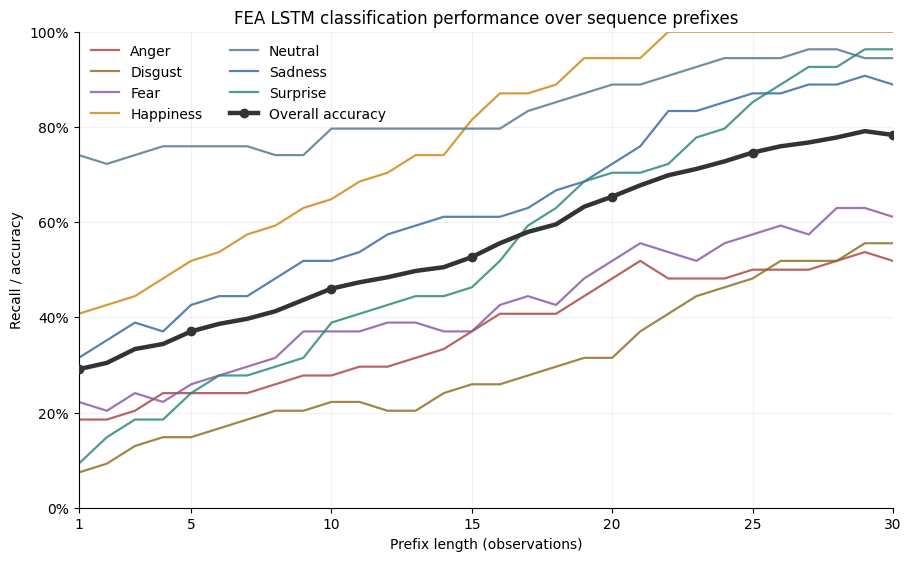

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

for k, class_name in enumerate(CLASSES):
    ax.plot(
        STEPS,
        recall[k],
        color=COLORS[k],
        linewidth=1.6,
        alpha=0.82,
        label=class_name,
    )

ax.plot(
    STEPS,
    overall['accuracy'],
    color='#333333',
    linewidth=3.2,
    marker='o',
    markevery=[0, 4, 9, 14, 19, 24, 29],
    label='Overall accuracy',
    zorder=10,
)

ax.set(
    xlabel='Prefix length (observations)',
    ylabel='Recall / accuracy',
    title='FEA LSTM classification performance over sequence prefixes',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(ncol=2, frameon=False)

finish_figure(
    fig,
    '14_class_recall_and_overall_accuracy',
    aliases=['fea_prefix_recall_accuracy'],
)

### 3.2 Mean true-class probability by class and overall

For each class, average the probability assigned to the expected class over its 54 sequences. The emphasized line averages across all 378 sequences. Because the test set is class-balanced, this is also the unweighted mean of the seven class-specific curves.

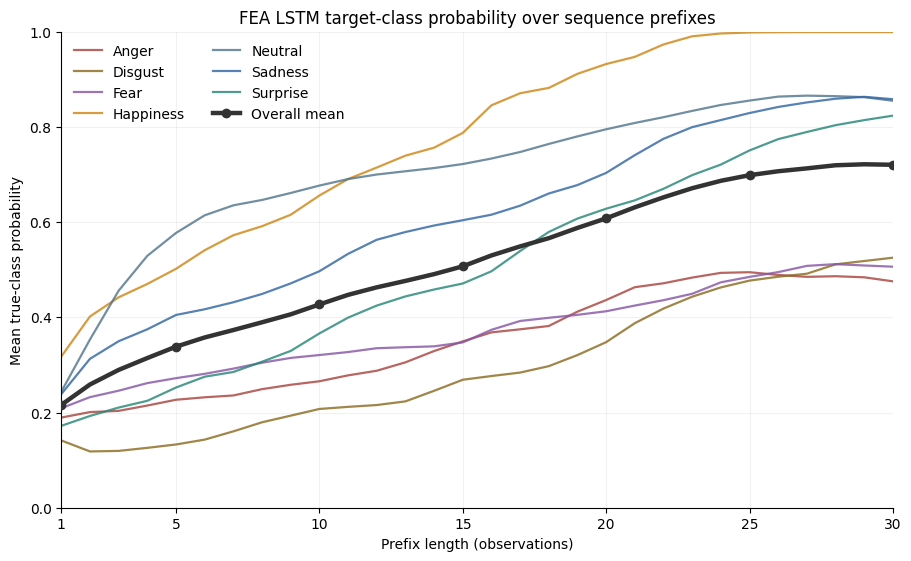

,prefix_length,Anger,Disgust,Fear,Happiness,Neutral,Sadness,Surprise,all_classes_mean
0,1,0.189375,0.141265,0.209048,0.317635,0.243789,0.238596,0.172019,0.215961
4,5,0.226796,0.132849,0.272143,0.501824,0.577172,0.404896,0.252420,0.338300
9,10,0.265624,0.207431,0.320755,0.655753,0.676693,0.496730,0.366117,0.427015
14,15,0.349387,0.268816,0.347244,0.787326,0.721932,0.603904,0.470971,0.507083
19,20,0.436253,0.347780,0.412694,0.932028,0.794964,0.703338,0.628111,0.607881
24,25,0.494717,0.477064,0.484906,0.998271,0.855248,0.829095,0.750521,0.698546
29,30,0.475547,0.525215,0.506319,0.999090,0.854838,0.858160,0.823568,0.720391


In [6]:
class_true_means = mean_true_by_class.copy()
overall_true_mean = TRUE_P.mean(axis=0)

assert np.allclose(
    overall_true_mean,
    class_true_means.mean(axis=0),
)

fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

for k, class_name in enumerate(CLASSES):
    ax.plot(
        STEPS,
        class_true_means[k],
        color=COLORS[k],
        linewidth=1.6,
        alpha=0.82,
        label=class_name,
    )

ax.plot(
    STEPS,
    overall_true_mean,
    color='#333333',
    linewidth=3.2,
    marker='o',
    markevery=[0, 4, 9, 14, 19, 24, 29],
    label='Overall mean',
    zorder=10,
)

ax.set(
    xlabel='Prefix length (observations)',
    ylabel='Mean true-class probability',
    title='FEA LSTM target-class probability over sequence prefixes',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)

ax.legend(ncol=2, frameon=False)

finish_figure(
    fig,
    '11_mean_true_class_probability',
    aliases=['fea_prefix_true_class_probability'],
)

summary = pd.DataFrame(
    class_true_means.T,
    columns=CLASSES,
)
summary.insert(0, 'prefix_length', STEPS)
summary['all_classes_mean'] = overall_true_mean
summary.to_csv(OUTPUT_DIR / 'mean_true_class_probability.csv', index=False)

summary.iloc[[0, 4, 9, 14, 19, 24, 29]]

### 3.3 Individual true-class probability trajectories by ground-truth class

Thin lines retain every individual sequence. The thick line is the class mean. The dotted reference is the uniform softmax probability `1/7`.

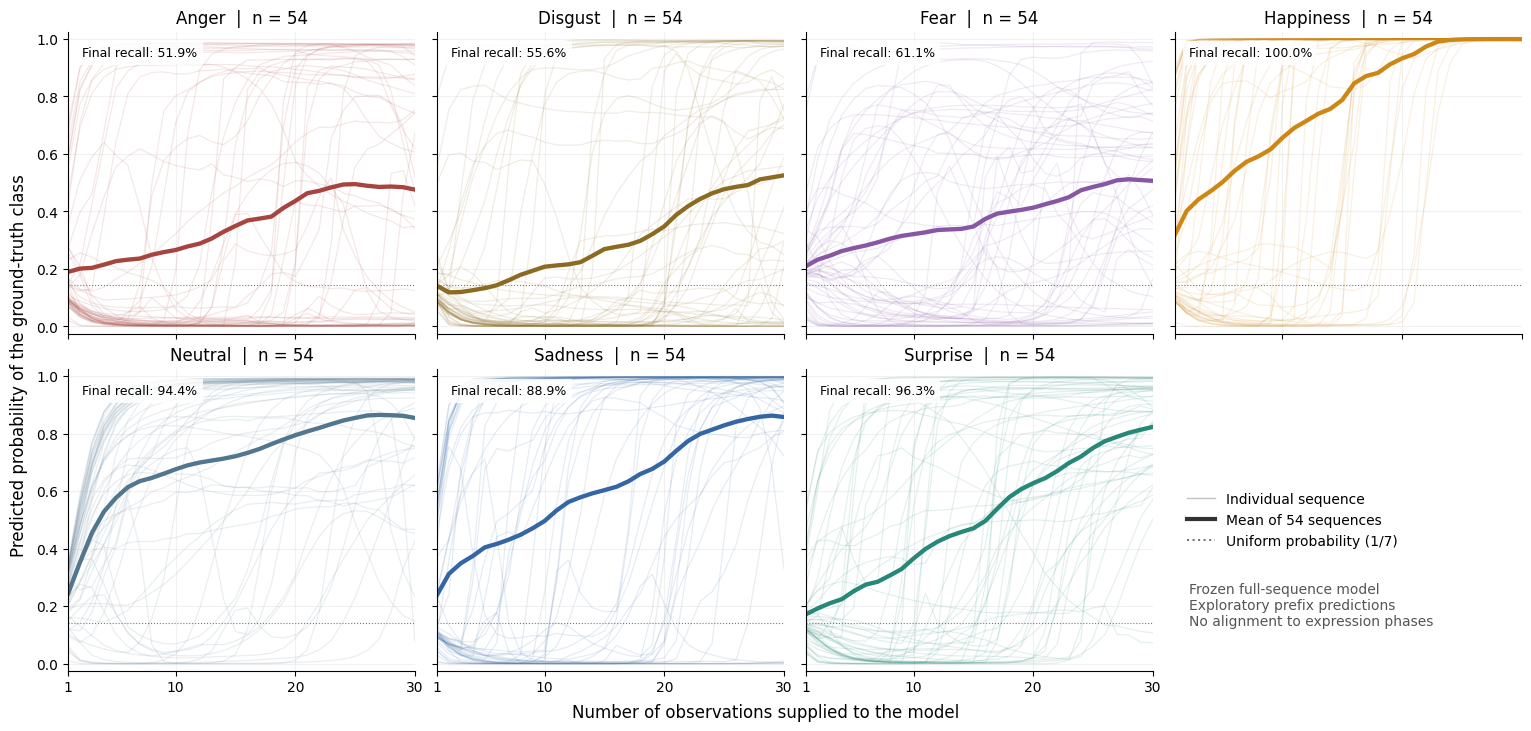

In [7]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(15.2, 7.2),
    sharex=True,
    sharey=True,
    layout='constrained',
)

for k, ax in enumerate(axes.flat[:7]):
    values = TRUE_P[Y == k]

    ax.plot(
        STEPS,
        values.T,
        color=COLORS[k],
        alpha=0.12,
        lw=0.9,
    )

    ax.plot(
        STEPS,
        values.mean(axis=0),
        color=COLORS[k],
        lw=3.1,
    )

    ax.axhline(
        1 / 7,
        color='#777777',
        ls=':',
        lw=0.8,
    )

    ax.set(
        title=f'{CLASSES[k]}  |  n = 54',
        xlim=(1, 30),
        ylim=(-0.025, 1.025),
        xticks=[1, 10, 20, 30],
    )

    ax.text(
        0.04,
        0.95,
        f'Final recall: {recall[k, -1]:.1%}',
        transform=ax.transAxes,
        va='top',
        fontsize=9,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.85,
        ),
    )

axes.flat[7].axis('off')

axes.flat[7].legend(
    handles=[
        Line2D([0], [0], color='#666666', lw=1, alpha=0.4, label='Individual sequence'),
        Line2D([0], [0], color='#333333', lw=3, label='Mean of 54 sequences'),
        Line2D([0], [0], color='#777777', ls=':', label='Uniform probability (1/7)'),
    ],
    loc='center left',
    frameon=False,
)

axes.flat[7].text(
    0.04,
    0.15,
    'Frozen full-sequence model\n'
    'Exploratory prefix predictions\n'
    'No alignment to expression phases',
    transform=axes.flat[7].transAxes,
    fontsize=10,
    color='#555555',
)

fig.supxlabel('Number of observations supplied to the model')
fig.supylabel('Predicted probability of the ground-truth class')

finish_figure(fig, '01_class_trajectories')

### 3.4 All individual true-class trajectories

This view ignores class identity and shows the true-class probability of every held-out sequence together with the overall mean.

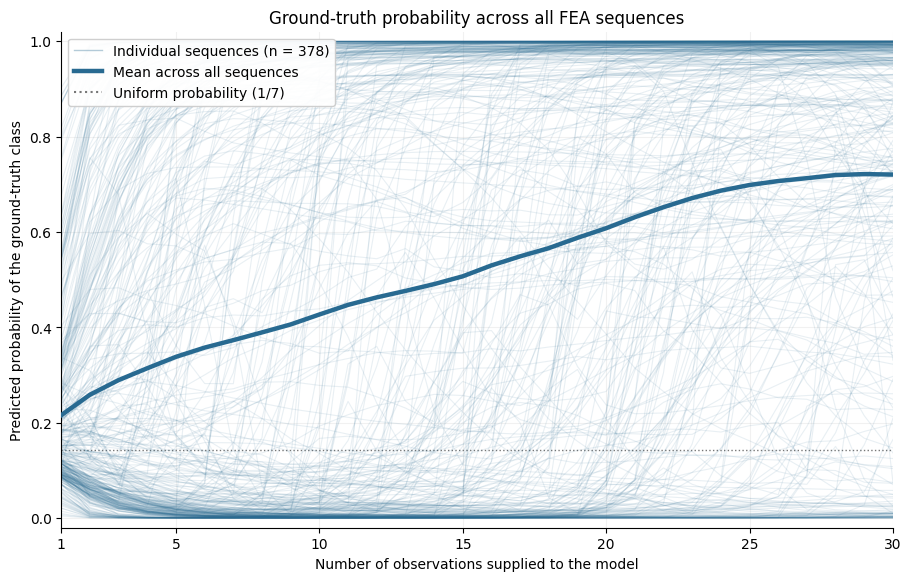

In [8]:
blue = '#286A91'

fig, ax = plt.subplots(figsize=(9, 5.7), layout='constrained')

ax.plot(
    STEPS,
    TRUE_P.T,
    color=blue,
    alpha=0.1,
    linewidth=0.8,
    zorder=2,
)

ax.plot(
    STEPS,
    TRUE_P.mean(axis=0),
    color=blue,
    linewidth=3.2,
    zorder=3,
)

ax.axhline(
    1 / 7,
    color='#777777',
    linestyle=':',
    linewidth=1,
    zorder=1,
)

ax.set(
    title='Ground-truth probability across all FEA sequences',
    xlabel='Number of observations supplied to the model',
    ylabel='Predicted probability of the ground-truth class',
    xlim=(1, 30),
    ylim=(-0.02, 1.02),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)

ax.legend(
    handles=[
        Line2D([], [], color=blue, linewidth=1, alpha=0.35,
               label=f'Individual sequences (n = {len(TRUE_P)})'),
        Line2D([], [], color=blue, linewidth=3.2,
               label='Mean across all sequences'),
        Line2D([], [], color='#777777', linestyle=':',
               label='Uniform probability (1/7)'),
    ],
    loc='upper left',
    framealpha=0.94,
)

finish_figure(fig, '08_all_sequence_trajectories')

## 4. Trajectories grouped by final prediction outcome

These analyses use the prediction after all 30 observations to define fixed retrospective groups. The grouping is descriptive and should not be interpreted as an independent test of input dynamics.

### 4.1 Overall true-class trajectories: final correct vs. final wrong

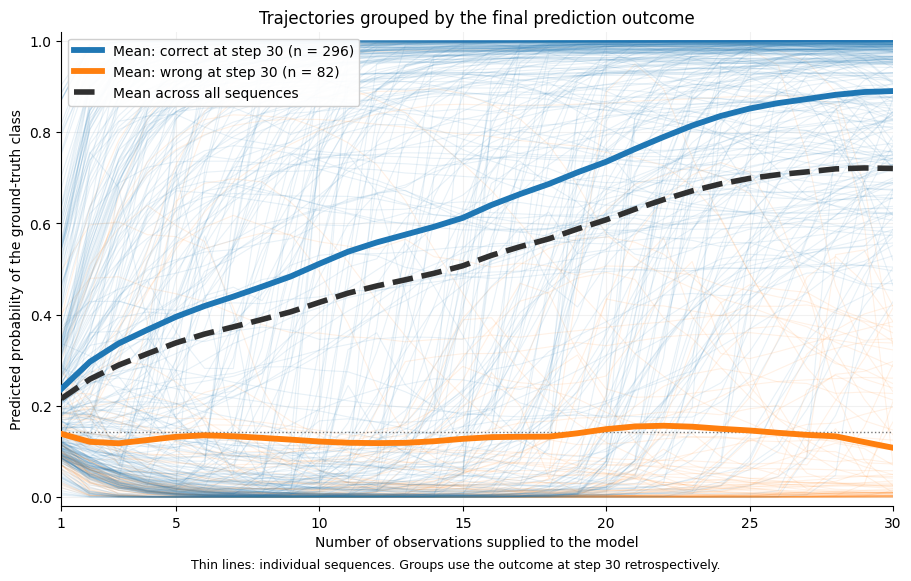

In [9]:
final_correct = CORRECT[:, -1]

mean_all = TRUE_P.mean(axis=0)
mean_correct = TRUE_P[final_correct].mean(axis=0)
mean_wrong = TRUE_P[~final_correct].mean(axis=0)

assert np.allclose(
    mean_all,
    final_correct.mean() * mean_correct
    + (~final_correct).mean() * mean_wrong,
)

fig, ax = plt.subplots(figsize=(9, 5.7), layout='constrained')

for mask, color in [
    (~final_correct, 'tab:orange'),
    (final_correct, 'tab:blue'),
]:
    ax.plot(
        STEPS,
        TRUE_P[mask].T,
        color=color,
        alpha=0.1,
        linewidth=0.8,
        zorder=2,
    )

ax.plot(
    STEPS,
    mean_correct,
    color='tab:blue',
    linewidth=4.2,
    zorder=4,
    label=f'Mean: correct at step 30 (n = {final_correct.sum()})',
)

ax.plot(
    STEPS,
    mean_wrong,
    color='tab:orange',
    linewidth=4.2,
    zorder=4,
    label=f'Mean: wrong at step 30 (n = {(~final_correct).sum()})',
)

ax.plot(
    STEPS,
    mean_all,
    color='#303030',
    linewidth=4,
    linestyle='--',
    zorder=3,
    label='Mean across all sequences',
)

ax.axhline(
    1 / 7,
    color='#777777',
    linestyle=':',
    linewidth=1,
)

ax.set(
    title='Trajectories grouped by the final prediction outcome',
    xlabel='Number of observations supplied to the model',
    ylabel='Predicted probability of the ground-truth class',
    xlim=(1, 30),
    ylim=(-0.02, 1.02),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)

ax.legend(loc='upper left', framealpha=0.94)

fig.supxlabel(
    'Thin lines: individual sequences. '
    'Groups use the outcome at step 30 retrospectively.',
    fontsize=9,
)

finish_figure(fig, '09_trajectories_by_final_outcome')

### 4.2 Class-wise true-class trajectories: final correct vs. final wrong

Each panel separates sequences by the final prediction outcome while preserving the ground-truth class.

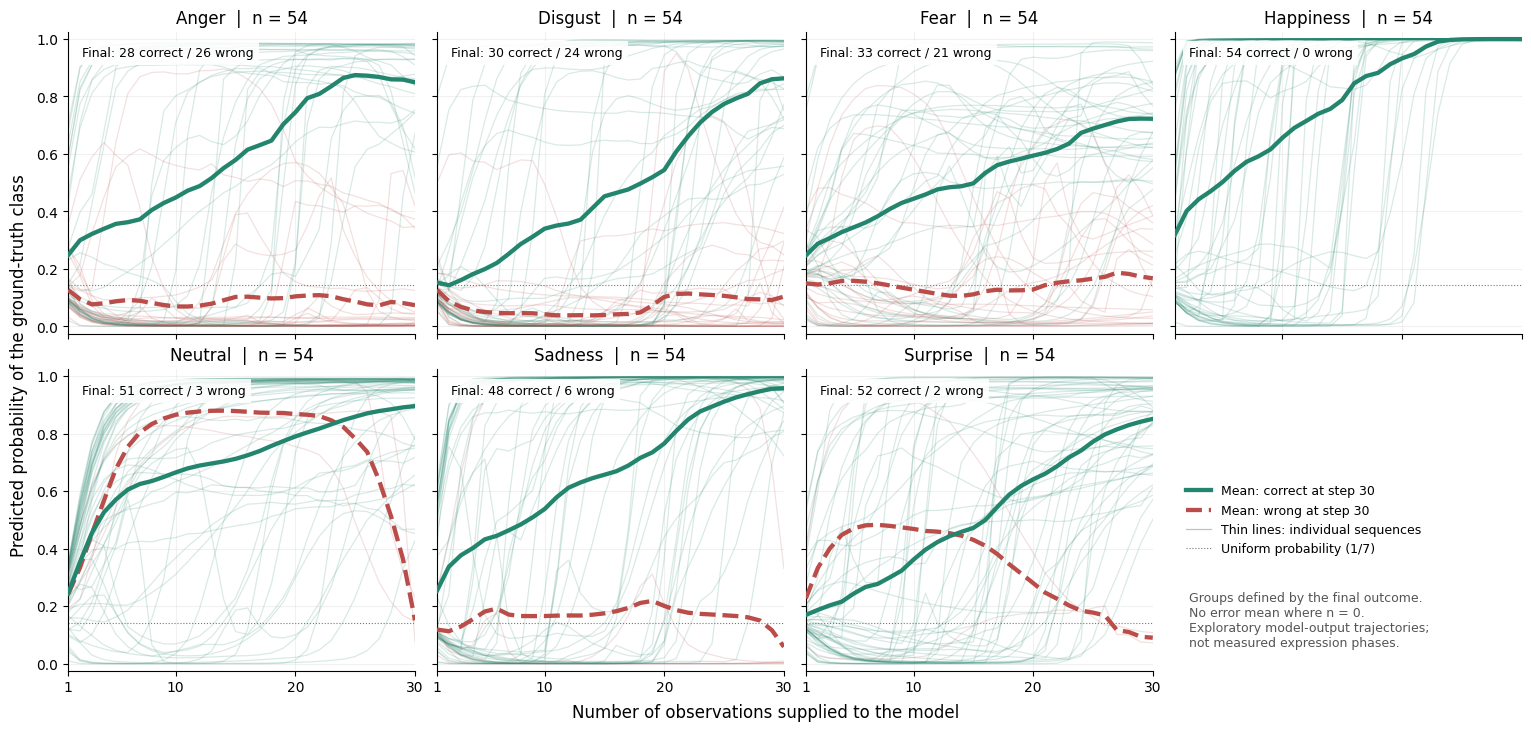

In [10]:
green, red = '#23856D', '#BA4D49'

fig, axes = plt.subplots(
    2, 4,
    figsize=(15.2, 7.2),
    sharex=True,
    sharey=True,
    layout='constrained',
)

for k, ax in enumerate(axes.flat[:7]):
    class_mask = Y == k
    correct_mask = class_mask & final_correct
    wrong_mask = class_mask & ~final_correct

    n_correct = int(correct_mask.sum())
    n_wrong = int(wrong_mask.sum())

    for mask, color in [
        (wrong_mask, red),
        (correct_mask, green),
    ]:
        values = TRUE_P[mask]
        if len(values):
            ax.plot(
                STEPS,
                values.T,
                color=color,
                alpha=0.17,
                lw=0.9,
            )

    for mask, color, linestyle in [
        (wrong_mask, red, '--'),
        (correct_mask, green, '-'),
    ]:
        values = TRUE_P[mask]

        if len(values):
            ax.plot(
                STEPS,
                values.mean(axis=0),
                color=color,
                ls=linestyle,
                lw=3.1,
                zorder=4,
            )

    ax.axhline(1 / 7, color='#777777', ls=':', lw=0.8)

    ax.set(
        title=f'{CLASSES[k]}  |  n = {class_mask.sum()}',
        xlim=(1, 30),
        ylim=(-0.025, 1.025),
        xticks=[1, 10, 20, 30],
    )

    ax.text(
        0.04,
        0.95,
        f'Final: {n_correct} correct / {n_wrong} wrong',
        transform=ax.transAxes,
        va='top',
        fontsize=9,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.88,
        ),
    )

legend_ax = axes.flat[7]
legend_ax.axis('off')

legend_ax.legend(
    handles=[
        Line2D([], [], color=green, lw=3.1,
               label='Mean: correct at step 30'),
        Line2D([], [], color=red, ls='--', lw=3.1,
               label='Mean: wrong at step 30'),
        Line2D([], [], color='#666666', lw=0.9, alpha=0.4,
               label='Thin lines: individual sequences'),
        Line2D([], [], color='#777777', ls=':', lw=0.8,
               label='Uniform probability (1/7)'),
    ],
    loc='center left',
    frameon=False,
    fontsize=9,
)

legend_ax.text(
    0.04,
    0.08,
    'Groups defined by the final outcome.\n'
    'No error mean where n = 0.\n'
    'Exploratory model-output trajectories;\n'
    'not measured expression phases.',
    transform=legend_ax.transAxes,
    fontsize=9,
    color='#555555',
)

fig.supxlabel('Number of observations supplied to the model')
fig.supylabel('Predicted probability of the ground-truth class')

finish_figure(fig, '10_class_trajectories_by_final_outcome')

## 5. Recognition, confidence, prediction composition, and stability

These views retain the broader exploratory diagnostics from the earlier trajectory notebook.

### 5.1 Overall recognition and confidence

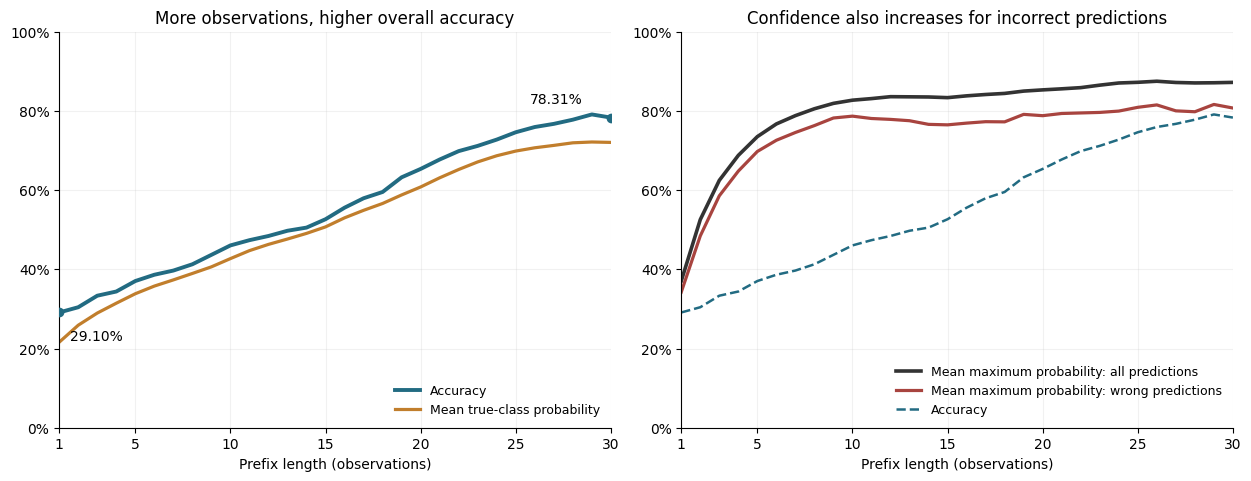

In [11]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12.4, 4.7),
    layout='constrained',
)

ax = axes[0]

ax.plot(
    STEPS,
    overall.accuracy,
    color='#226B82',
    lw=2.8,
    label='Accuracy',
)

ax.plot(
    STEPS,
    overall.mean_true_probability,
    color='#C17E2C',
    lw=2.3,
    label='Mean true-class probability',
)

ax.scatter(
    [1, 30],
    overall.accuracy.iloc[[0, -1]],
    color='#226B82',
    zorder=4,
)

ax.annotate(
    f'{overall.accuracy.iloc[0]:.2%}',
    (1, overall.accuracy.iloc[0]),
    xytext=(8, -20),
    textcoords='offset points',
)

ax.annotate(
    f'{overall.accuracy.iloc[-1]:.2%}',
    (30, overall.accuracy.iloc[-1]),
    xytext=(-58, 10),
    textcoords='offset points',
)

ax.set_title('More observations, higher overall accuracy')
ax.legend(loc='lower right', frameon=False, fontsize=9)

ax = axes[1]

ax.plot(
    STEPS,
    overall.mean_max_probability,
    color='#333333',
    lw=2.6,
    label='Mean maximum probability: all predictions',
)

ax.plot(
    STEPS,
    overall.mean_confidence_when_wrong,
    color='#A8443F',
    lw=2.3,
    label='Mean maximum probability: wrong predictions',
)

ax.plot(
    STEPS,
    overall.accuracy,
    color='#226B82',
    lw=1.8,
    ls='--',
    label='Accuracy',
)

ax.set_title('Confidence also increases for incorrect predictions')
ax.legend(loc='lower right', frameon=False, fontsize=9)

for ax in axes:
    ax.set(
        xlim=(1, 30),
        ylim=(0, 1),
        xticks=[1, 5, 10, 15, 20, 25, 30],
        xlabel='Prefix length (observations)',
    )
    ax.yaxis.set_major_formatter(PercentFormatter(1))

finish_figure(fig, '02_accuracy_and_confidence')

### 5.2 Class recall heatmap and prediction composition

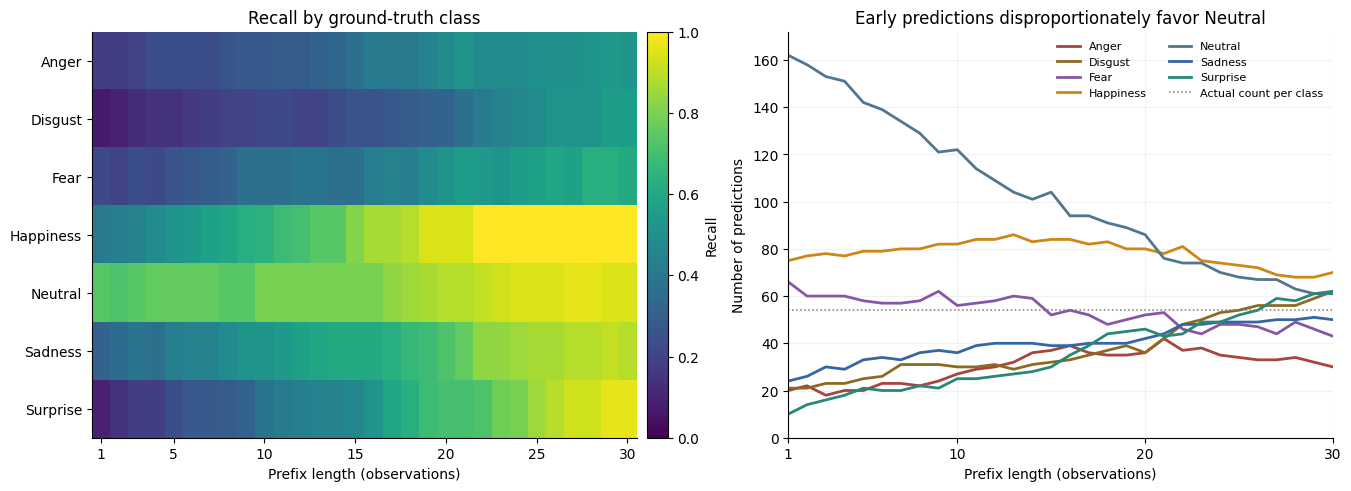

In [12]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(13.4, 4.8),
    layout='constrained',
)

im = axes[0].imshow(
    recall,
    aspect='auto',
    vmin=0,
    vmax=1,
    cmap='viridis',
    extent=(0.5, 30.5, 6.5, -0.5),
)

axes[0].set(
    yticks=range(7),
    yticklabels=CLASSES,
    xticks=[1, 5, 10, 15, 20, 25, 30],
    xlabel='Prefix length (observations)',
    title='Recall by ground-truth class',
)

axes[0].grid(False)

fig.colorbar(
    im,
    ax=axes[0],
    label='Recall',
    fraction=0.046,
    pad=0.02,
)

for k in range(7):
    axes[1].plot(
        STEPS,
        predicted_counts[:, k],
        color=COLORS[k],
        label=CLASSES[k],
        lw=2,
    )

axes[1].axhline(
    54,
    color='#777777',
    ls=':',
    lw=1.1,
    label='Actual count per class',
)

axes[1].set(
    xlim=(1, 30),
    ylim=(0, max(predicted_counts.max() + 10, 170)),
    xticks=[1, 10, 20, 30],
    xlabel='Prefix length (observations)',
    ylabel='Number of predictions',
    title='Early predictions disproportionately favor Neutral',
)

axes[1].legend(
    loc='upper right',
    fontsize=8,
    frameon=False,
    ncol=2,
)

finish_figure(fig, '03_class_recall_and_composition')

### 5.3 Corrections, reversals, and retrospective stability

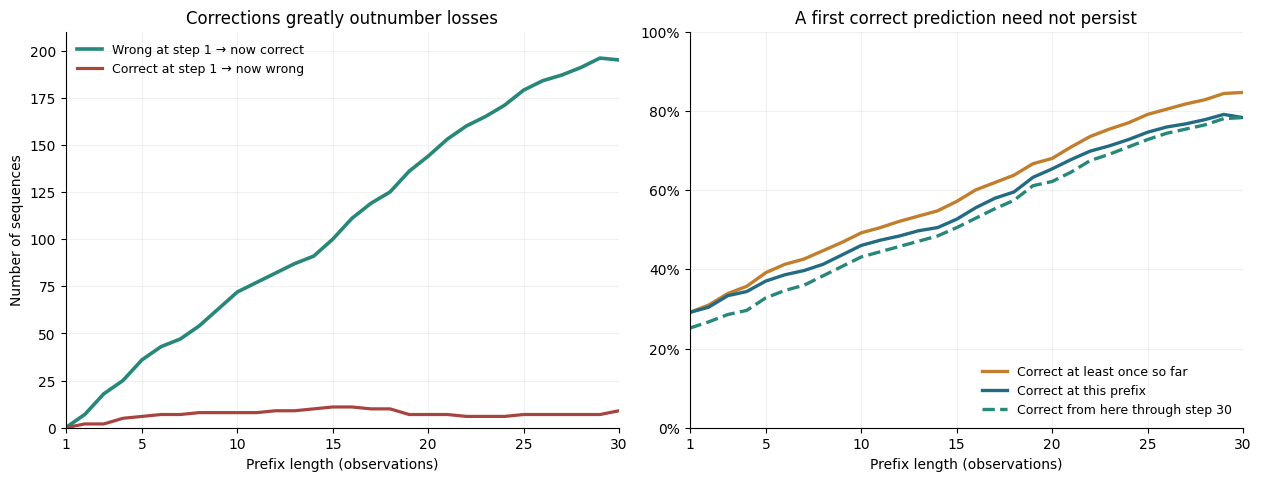

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 4.7),
    layout='constrained',
)

axes[0].plot(
    STEPS,
    recovery.corrected_since_t1,
    color='#278778',
    lw=2.6,
    label='Wrong at step 1 → now correct',
)

axes[0].plot(
    STEPS,
    recovery.lost_since_t1,
    color='#A8443F',
    lw=2.3,
    label='Correct at step 1 → now wrong',
)

axes[0].set(
    title='Corrections greatly outnumber losses',
    ylabel='Number of sequences',
    ylim=(0, 210),
)

axes[0].legend(
    loc='upper left',
    frameon=False,
    fontsize=9,
)

axes[1].plot(
    STEPS,
    recovery.ever_correct_so_far / N_SEQUENCES,
    color='#C17E2C',
    lw=2.4,
    label='Correct at least once so far',
)

axes[1].plot(
    STEPS,
    overall.accuracy,
    color='#226B82',
    lw=2.4,
    label='Correct at this prefix',
)

axes[1].plot(
    STEPS,
    recovery.correct_through_final / N_SEQUENCES,
    color='#278778',
    lw=2.4,
    ls='--',
    label='Correct from here through step 30',
)

axes[1].set(
    title='A first correct prediction need not persist',
    ylim=(0, 1),
)

axes[1].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].legend(
    loc='lower right',
    frameon=False,
    fontsize=9,
)

for ax in axes:
    ax.set(
        xlim=(1, 30),
        xticks=[1, 5, 10, 15, 20, 25, 30],
        xlabel='Prefix length (observations)',
    )

finish_figure(fig, '04_corrections_and_stability')

### 5.4 Confusion matrices at fixed descriptive checkpoints

Counts are shown at prefixes 1, 10, 20, and 30. Each ground-truth row contains 54 sequences, and all panels use the same color scale.

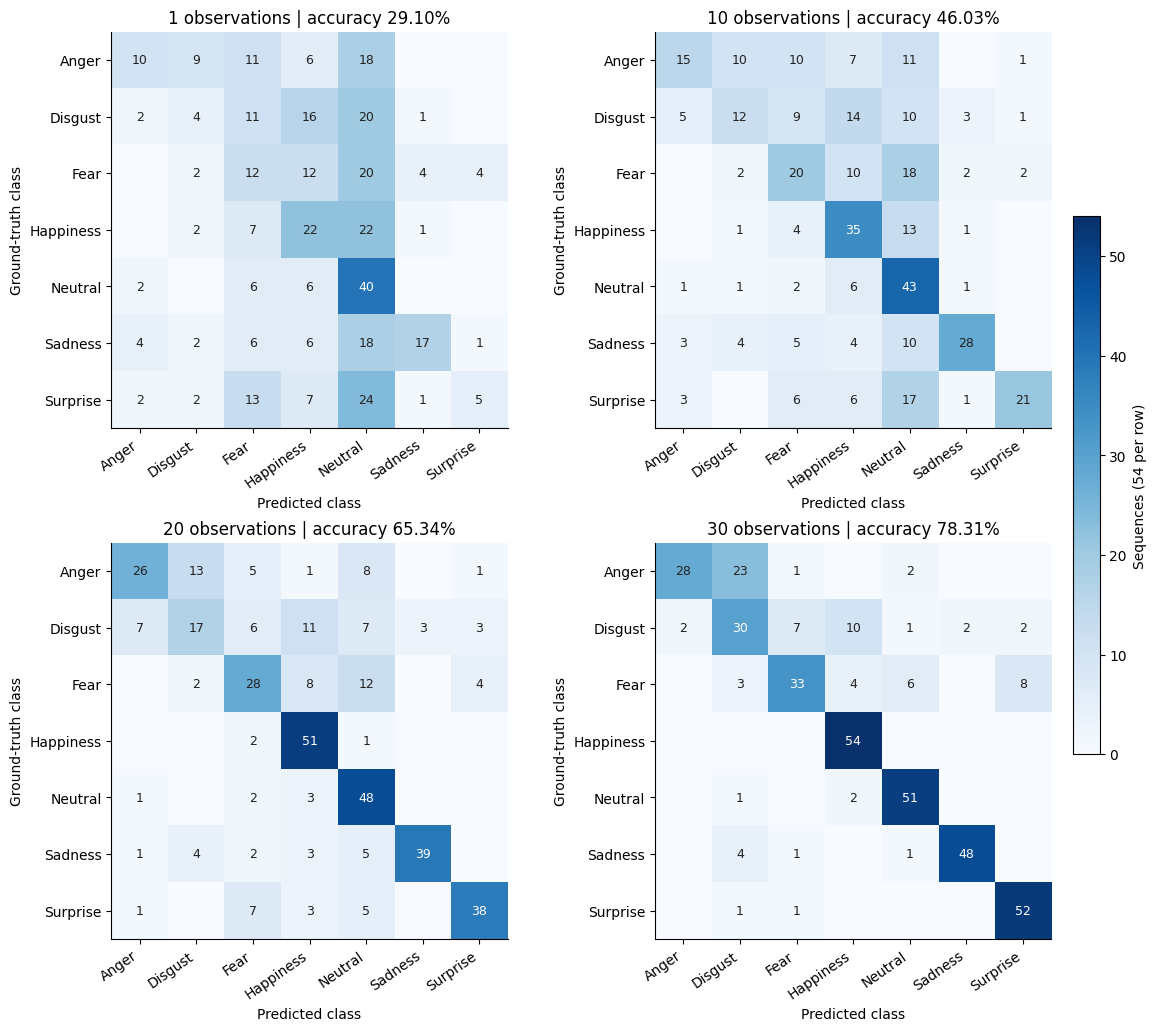

In [14]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(11.8, 10.2),
    layout='constrained',
)

confusion_rows = []

for ax, t in zip(axes.flat, [1, 10, 20, 30]):
    cm = np.zeros((7, 7), dtype=int)
    np.add.at(cm, (Y, PRED[:, t - 1]), 1)

    im = ax.imshow(
        cm,
        vmin=0,
        vmax=54,
        cmap='Blues',
    )

    for i in range(7):
        for j in range(7):
            if cm[i, j]:
                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='white' if cm[i, j] > 29 else '#222222',
                )

            confusion_rows.append({
                'prefix_length': t,
                'true_class': CLASSES[i],
                'predicted_class': CLASSES[j],
                'count': int(cm[i, j]),
                'row_proportion': float(cm[i, j] / 54),
            })

    ax.set(
        xticks=range(7),
        xticklabels=CLASSES,
        yticks=range(7),
        yticklabels=CLASSES,
        title=f'{t} observations | accuracy {CORRECT[:, t - 1].mean():.2%}',
        xlabel='Predicted class',
        ylabel='Ground-truth class',
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha='right',
    )

    ax.grid(False)

fig.colorbar(
    im,
    ax=axes,
    label='Sequences (54 per row)',
    fraction=0.025,
    pad=0.02,
)

pd.DataFrame(confusion_rows).to_csv(
    TABLE_DIR / 'confusions_at_fixed_prefixes.csv',
    index=False,
)

finish_figure(fig, '05_error_patterns')

## 6. Individual examples and participant-level descriptive checks

The example-selection rule is deterministic: within each predefined outcome group, select the trajectory closest to that group's mean seven-class probability trajectory.

### 6.1 Reproducibly selected individual examples

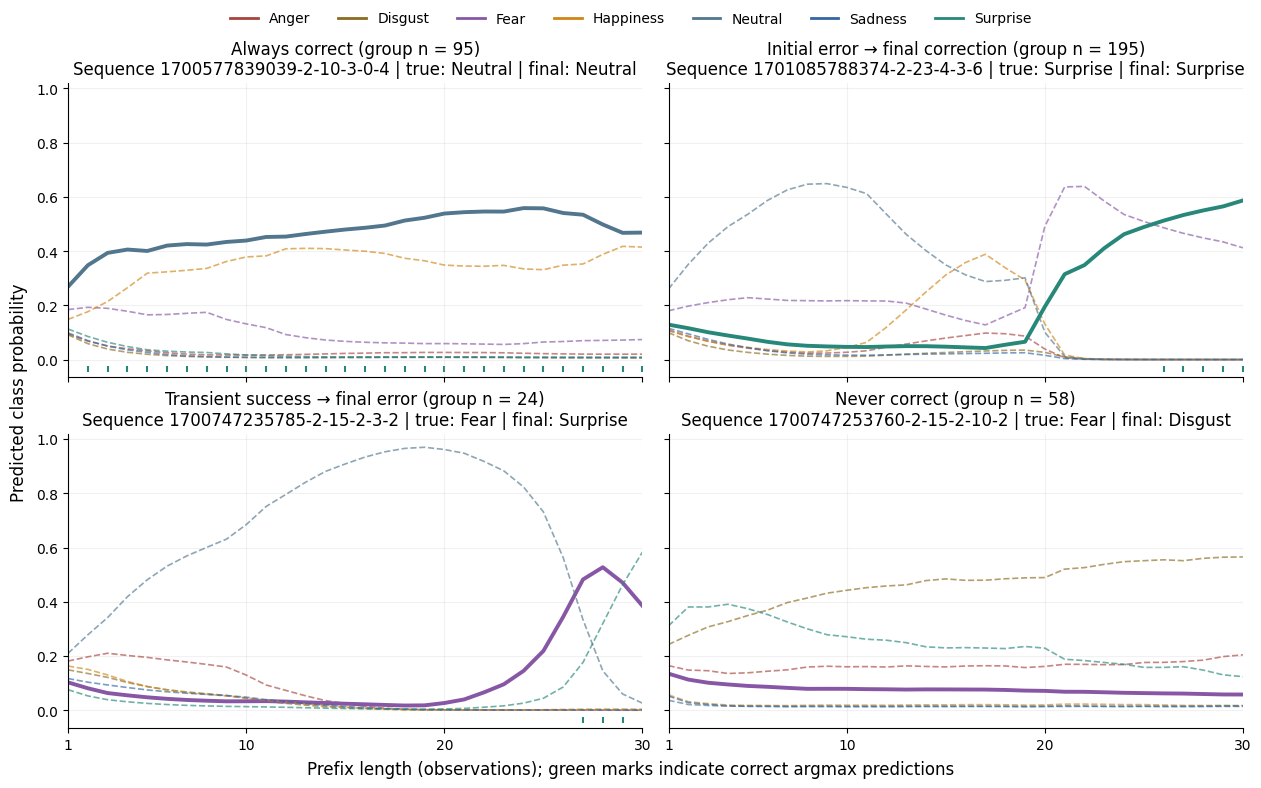

In [15]:
example_groups = {
    'Always correct': CORRECT.all(axis=1),
    'Initial error → final correction': (~CORRECT[:, 0]) & CORRECT[:, -1],
    'Transient success → final error': CORRECT.any(axis=1) & (~CORRECT[:, -1]),
    'Never correct': ~CORRECT.any(axis=1),
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12.5, 7.8),
    sharex=True,
    sharey=True,
    layout='constrained',
)

example_rows = []

for ax, (group_name, mask) in zip(axes.flat, example_groups.items()):
    candidates = np.flatnonzero(mask)

    if not len(candidates):
        ax.set_title(f'{group_name}: no sequences')
        continue

    center = P[candidates].mean(axis=0)
    distance = ((P[candidates] - center) ** 2).mean(axis=(1, 2))
    i = candidates[np.argmin(distance)]

    for k in range(7):
        ax.plot(
            STEPS,
            P[i, :, k],
            color=COLORS[k],
            lw=2.8 if k == Y[i] else 1.2,
            ls='-' if k == Y[i] else '--',
            alpha=1 if k == Y[i] else 0.65,
        )

    ax.scatter(
        STEPS[CORRECT[i]],
        np.full(CORRECT[i].sum(), -0.035),
        color='#278778',
        marker='|',
        s=25,
    )

    ax.set(
        title=(
            f'{group_name} (group n = {len(candidates)})\n'
            f'Sequence {SEQUENCE_IDS[i]} | '
            f'true: {CLASSES[Y[i]]} | '
            f'final: {CLASSES[PRED[i, -1]]}'
        ),
        xlim=(1, 30),
        ylim=(-0.065, 1.02),
        xticks=[1, 10, 20, 30],
    )

    example_rows.append({
        'group': group_name,
        'group_n': len(candidates),
        'sequence_id': SEQUENCE_IDS[i],
        'true_class': CLASSES[Y[i]],
        'final_class': CLASSES[PRED[i, -1]],
        'distance_to_group_mean': float(distance.min()),
    })

fig.supxlabel(
    'Prefix length (observations); green marks indicate correct argmax predictions'
)
fig.supylabel('Predicted class probability')

fig.legend(
    handles=[
        Line2D([0], [0], color=COLORS[k], lw=2, label=name)
        for k, name in enumerate(CLASSES)
    ],
    loc='outside upper center',
    ncol=7,
    frameon=False,
)

pd.DataFrame(example_rows).to_csv(
    TABLE_DIR / 'selected_examples.csv',
    index=False,
)

finish_figure(fig, '06_selected_examples')

### 6.2 Participant-level descriptive check

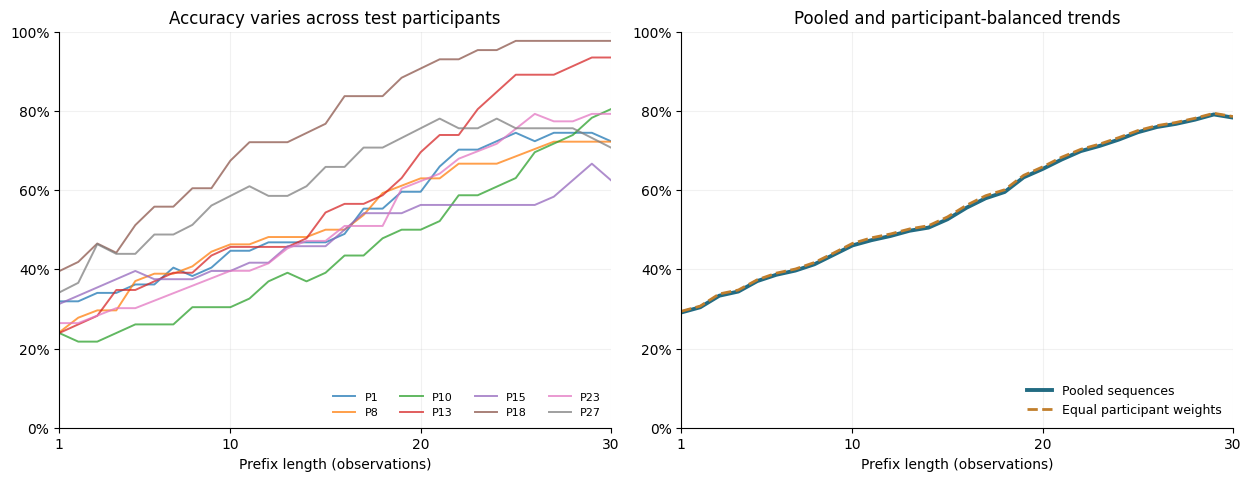

Participants improving from prefix 1 to 30: 8/8
Maximum pooled vs. equal-participant accuracy difference: 0.637 pp


In [16]:
participants = np.sort(metadata['participant_id'].unique())

participant_acc = np.array([
    CORRECT[
        metadata['participant_id'].eq(pid).to_numpy()
    ].mean(axis=0)
    for pid in participants
])

participant_rows = []

for pid, values in zip(participants, participant_acc):
    mask = metadata['participant_id'].eq(pid).to_numpy()

    for t, value in zip(STEPS, values):
        participant_rows.append({
            'participant_id': int(pid),
            'n_sequences': int(mask.sum()),
            'prefix_length': int(t),
            'accuracy': float(value),
        })

participant_df = pd.DataFrame(participant_rows)

participant_df.to_csv(
    TABLE_DIR / 'participant_accuracy_by_prefix.csv',
    index=False,
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.4, 4.7),
    layout='constrained',
)

for pid, values in zip(participants, participant_acc):
    axes[0].plot(
        STEPS,
        values,
        lw=1.4,
        alpha=0.75,
        label=f'P{pid}',
    )

axes[0].set(
    title='Accuracy varies across test participants',
    xlabel='Prefix length (observations)',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)

axes[0].legend(
    ncol=4,
    loc='lower right',
    fontsize=8,
    frameon=False,
)

axes[1].plot(
    STEPS,
    CORRECT.mean(axis=0),
    color='#226B82',
    lw=2.8,
    label='Pooled sequences',
)

axes[1].plot(
    STEPS,
    participant_acc.mean(axis=0),
    color='#C17E2C',
    lw=2,
    ls='--',
    label='Equal participant weights',
)

axes[1].set(
    title='Pooled and participant-balanced trends',
    xlabel='Prefix length (observations)',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)

axes[1].legend(
    loc='lower right',
    frameon=False,
    fontsize=9,
)

for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))

finish_figure(fig, '07_participant_check')

print(
    'Participants improving from prefix 1 to 30:',
    f'{(participant_acc[:, -1] > participant_acc[:, 0]).sum()}/{len(participants)}',
)

print(
    'Maximum pooled vs. equal-participant accuracy difference:',
    f'{100 * np.abs(participant_acc.mean(axis=0) - CORRECT.mean(axis=0)).max():.3f} pp',
)

## 7. Detailed class-probability views

These plots retain all seven output-class probabilities, rather than only the true-class probability.

- **All sequences:** all 54 sequences of each ground-truth class.
- **Final errors:** the fixed subset incorrectly classified at prefix 30.

Standalone class panels and overview grids are exported as PNG and vector PDF.

### 7.1 Shared plotting helpers

In [17]:
def configure_probability_axis(ax):
    ax.set(
        xlim=(1, 30),
        ylim=(-0.025, 1.025),
        xticks=[1, 10, 20, 30],
    )


def probability_panel(
    ax,
    true_class_id,
    mask,
    individuals=False,
    error_individuals=False,
):
    count = int(mask.sum())

    ax.set_title(
        f'{CLASSES[true_class_id]} | n = {count}'
    )

    configure_probability_axis(ax)

    if count == 0:
        ax.text(
            0.5,
            0.5,
            'No final errors\nMean trajectories undefined',
            transform=ax.transAxes,
            ha='center',
            va='center',
            color='#666666',
        )
        return

    values = P[mask]

    if error_individuals:
        true_lines = values[:, :, true_class_id]
        final_labels = PRED[mask, -1]

        assert np.all(final_labels != true_class_id)

        predicted_lines = np.take_along_axis(
            values,
            final_labels[:, None, None],
            axis=2,
        ).squeeze(axis=2)

        ax.plot(
            STEPS,
            true_lines.T,
            color='#23856D',
            alpha=0.16,
            lw=0.8,
            zorder=1,
        )

        ax.plot(
            STEPS,
            predicted_lines.T,
            color='#BA4D49',
            alpha=0.16,
            lw=0.8,
            zorder=1,
        )

    if individuals:
        for j in range(7):
            ax.plot(
                STEPS,
                values[:, :, j].T,
                color=COLORS[j],
                lw=0.6,
                alpha=0.09 if j == true_class_id else 0.035,
                zorder=1,
            )

    means = values.mean(axis=0)

    for j in [
        i for i in range(7)
        if i != true_class_id
    ] + [true_class_id]:
        expected = j == true_class_id

        ax.plot(
            STEPS,
            means[:, j],
            color=COLORS[j],
            lw=3.3 if expected else 1.6,
            ls='-' if expected else '--',
            alpha=1 if expected else 0.9,
            zorder=4 if expected else 3,
        )


def class_legend(true_class_id=None):
    return [
        Line2D(
            [],
            [],
            color=COLORS[j],
            lw=3.3 if j == true_class_id else 1.6,
            ls='-' if j == true_class_id else '--',
            label=name + (' (true)' if j == true_class_id else ''),
        )
        for j, name in enumerate(CLASSES)
    ]


def export_probability_family(errors_only, prefix):
    # Export seven standalone panels without displaying them.
    for k in range(7):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if errors_only
                else np.ones(len(Y), dtype=bool)
            )
        )

        fig, ax = plt.subplots(
            figsize=(8.8, 5.4),
            layout='constrained',
        )

        probability_panel(
            ax,
            k,
            mask,
            individuals=SHOW_INDIVIDUALS and not errors_only,
            error_individuals=errors_only,
        )

        ax.set(
            xlabel='Number of observations seen',
            ylabel='Predicted class probability',
        )

        handles = class_legend(k)

        if errors_only:
            handles += [
                Line2D(
                    [], [],
                    color='#23856D',
                    alpha=0.45,
                    lw=1,
                    label='Individual: true',
                ),
                Line2D(
                    [], [],
                    color='#BA4D49',
                    alpha=0.45,
                    lw=1,
                    label='Individual: final predicted',
                ),
            ]

        fig.legend(
            handles=handles,
            loc='outside lower center',
            ncol=3,
            frameon=False,
            fontsize=9,
        )

        fig.suptitle(
            'Final errors only'
            if errors_only
            else 'All sequences of the ground-truth class',
            fontsize=12,
        )

        finish_figure(
            fig,
            f'{prefix}_{CLASSES[k].lower()}',
            show=False,
        )

    # Compact overview grid.
    fig, axes = plt.subplots(
        2, 4,
        figsize=(15.2, 7.6),
        sharex=True,
        sharey=True,
        layout='constrained',
    )

    for k, ax in enumerate(axes.flat[:7]):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if errors_only
                else np.ones(len(Y), dtype=bool)
            )
        )

        probability_panel(
            ax,
            k,
            mask,
            individuals=SHOW_INDIVIDUALS and not errors_only,
            error_individuals=errors_only,
        )

    legend_ax = axes.flat[7]
    legend_ax.axis('off')

    handles = [
        Line2D(
            [],
            [],
            color=COLORS[j],
            lw=2,
            label=c,
        )
        for j, c in enumerate(CLASSES)
    ]

    legend_ax.legend(
        handles=handles,
        loc='upper left',
        ncol=2,
        fontsize=9,
        frameon=False,
    )

    note = (
        'Thick solid mean: ground-truth class\n'
        'Thin dashed means: other classes\n'
        + (
            'Faint green: individual true class\n'
            'Faint red: individual final predicted class\n'
            'Fixed groups: wrong at step 30'
            if errors_only
            else (
                'Faint lines: individual sequences'
                if SHOW_INDIVIDUALS
                else 'All curves: class-conditional means'
            )
        )
    )

    legend_ax.text(
        0.04,
        0.15,
        note,
        transform=legend_ax.transAxes,
        fontsize=9,
        color='#555555',
    )

    fig.supxlabel('Number of observations seen')
    fig.supylabel('Predicted class probability')

    fig.suptitle(
        'Final errors: mean and individual output probabilities'
        if errors_only
        else 'Output probabilities within each ground-truth class',
        fontsize=14,
    )

    finish_figure(fig, prefix + '_overview')

### 7.2 All seven output probabilities within each ground-truth class

Faint lines show individual probability trajectories for all seven outputs. Strong curves show the corresponding group means; the expected class is emphasized.

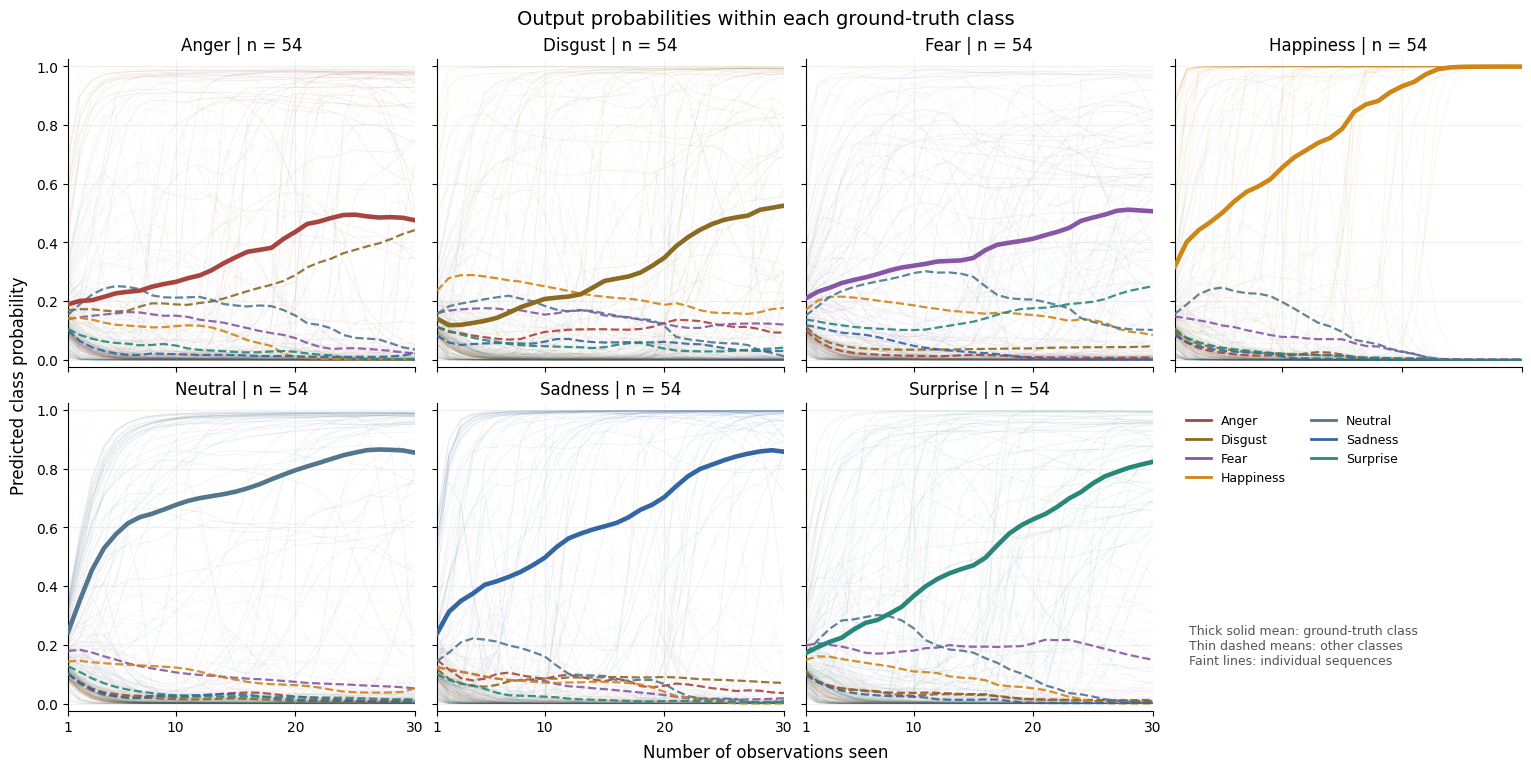

In [18]:
export_probability_family(
    errors_only=False,
    prefix='12_all_class_probabilities',
)

### 7.3 Final errors: output probabilities within each ground-truth class

The error subset is defined once using the prefix-30 argmax and kept fixed for every earlier prefix. Each error sequence contributes two faint lines: its true-class probability and the probability of its final predicted class.

Final-error counts by class: {'Anger': 26, 'Disgust': 24, 'Fear': 21, 'Happiness': 0, 'Neutral': 3, 'Sadness': 6, 'Surprise': 2}


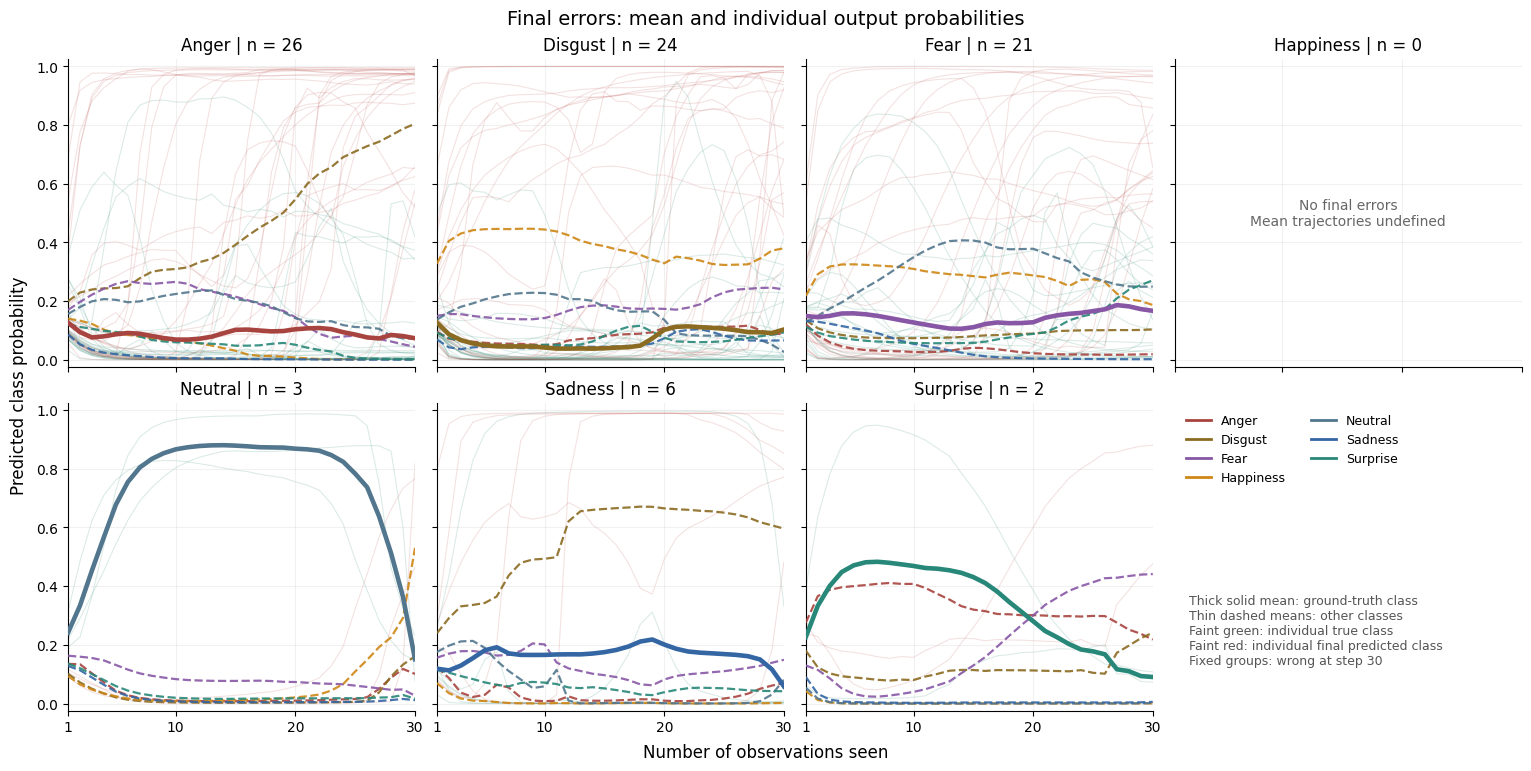

In [19]:
error_counts = {
    CLASSES[k]: int(((Y == k) & ~final_correct).sum())
    for k in range(7)
}

print('Final-error counts by class:', error_counts)

export_probability_family(
    errors_only=True,
    prefix='13_final_error_probabilities',
)

### 7.4 Export class-conditional probability means

The long-form CSV records all seven output means for all ground-truth classes, all 30 prefixes, and both the complete and final-error subsets.

In [20]:
rows = []

for subset in ['all', 'final_errors']:
    for k in range(7):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if subset == 'final_errors'
                else np.ones(len(Y), dtype=bool)
            )
        )

        n = int(mask.sum())

        means = (
            P[mask].mean(axis=0)
            if n
            else np.full((SEQUENCE_LENGTH, 7), np.nan)
        )

        if n:
            assert np.allclose(
                means.sum(axis=1),
                1,
                atol=1e-6,
            )

        for t in range(SEQUENCE_LENGTH):
            for j in range(7):
                rows.append({
                    'subset': subset,
                    'true_class': CLASSES[k],
                    'output_class': CLASSES[j],
                    'prefix_length': t + 1,
                    'n_sequences': n,
                    'mean_probability': means[t, j],
                })

means_df = pd.DataFrame(rows)

means_df.to_csv(
    OUTPUT_DIR / 'class_conditional_probability_means.csv',
    index=False,
)

print(
    f'Exported {len(means_df):,} class-conditional mean rows.'
)

Exported 2,940 class-conditional mean rows.


## 8. Results report and provenance

Generate a compact Markdown and self-contained HTML report, plus SHA-256 hashes and software versions. The report intentionally stays descriptive and does not infer expression phases from prefix positions.

In [21]:
def markdown_table(table):
    cols = [str(c) for c in table.columns]
    lines = [
        '| ' + ' | '.join(cols) + ' |',
        '| ' + ' | '.join(['---'] * len(cols)) + ' |',
    ]

    for row in table.itertuples(index=False, name=None):
        lines.append(
            '| ' + ' | '.join(str(v) for v in row) + ' |'
        )

    return '\n'.join(lines)


checkpoint_table = pd.DataFrame({
    'Prefix': [1, 5, 10, 15, 20, 25, 30],
    'Correct / 378': [
        f'{int(overall.loc[t - 1, "n_correct"])}/378'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
    'Accuracy': [
        f'{overall.loc[t - 1, "accuracy"]:.2%}'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
    'Mean true-class probability': [
        f'{overall.loc[t - 1, "mean_true_probability"]:.3f}'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
})

class_table = pd.DataFrame({
    'Class': CLASSES,
    'Recall, 1 observation': [
        f'{v:.2%}' for v in recall[:, 0]
    ],
    'Recall, 30 observations': [
        f'{v:.2%}' for v in recall[:, -1]
    ],
    'Never correct': class_summary.never_correct,
    'Earlier correct, final wrong':
        class_summary.earlier_correct_final_wrong,
})

peak_index = int(np.argmax(overall.accuracy))
final_error_n = int((~CORRECT[:, -1]).sum())
late_gains = int(((~CORRECT[:, 19]) & CORRECT[:, -1]).sum())
late_losses = int((CORRECT[:, 19] & (~CORRECT[:, -1])).sum())

final_cm = np.zeros((7, 7), dtype=int)
np.add.at(final_cm, (Y, PRED[:, -1]), 1)

error_pairs = sorted(
    [
        (
            int(final_cm[i, j]),
            CLASSES[i],
            CLASSES[j],
        )
        for i in range(7)
        for j in range(7)
        if i != j
    ],
    reverse=True,
)

error_text = '; '.join(
    f'{a} → {b}: {n}'
    for n, a, b in error_pairs[:4]
)


final_predicted_class = PRED[:, -1]
final_predicted_probability = np.take_along_axis(
    P,
    final_predicted_class[:, None, None],
    axis=2,
).squeeze(axis=2)

competition_rows = []
for k, class_name in enumerate(CLASSES):
    mask = Y == k
    final_mean = P[mask, -1].mean(axis=0)
    competitors = [j for j in range(7) if j != k]
    strongest_competitor = max(competitors, key=lambda j: final_mean[j])

    competition_rows.append({
        'True class': class_name,
        'Mean true-class p, prefix 30': f'{final_mean[k]:.3f}',
        'Strongest competing class': CLASSES[strongest_competitor],
        'Mean competing p, prefix 30': f'{final_mean[strongest_competitor]:.3f}',
    })

competition_table = pd.DataFrame(competition_rows)

sections = []

def section(
    title,
    text,
    table=None,
    figure=None,
    caption=None,
):
    sections.append({
        'title': title,
        'text': text,
        'table': table,
        'figure': figure,
        'caption': caption,
    })


section(
    'Main findings',
    f'The frozen ordered FEA model becomes more accurate as it receives longer prefixes: '
    f'{CORRECT[:, 0].sum()}/378 ({CORRECT[:, 0].mean():.2%}) at one observation and '
    f'{CORRECT[:, -1].sum()}/378 ({CORRECT[:, -1].mean():.2%}) at 30 observations. '
    f'The increase is {100 * (CORRECT[:, -1].mean() - CORRECT[:, 0].mean()):.2f} percentage points. '
    'This is an exploratory within-model prefix result, not the gain over a separately trained static model. '
    'The class trajectories show substantial heterogeneity, so the rising overall average does not imply monotonic improvement for every sequence.',
    checkpoint_table,
    '14_class_recall_and_overall_accuracy',
    'Class-specific recall trajectories with overall accuracy emphasized.',
)

section(
    'Input integrity and provenance',
    f'All {len(df):,} rows form 378 complete 30-step trajectories, with 54 sequences per class and eight test participants. '
    'There are no missing values or duplicate sequence-step pairs. '
    'Labels, argmax predictions, true/max probability columns, correctness flags, sample IDs, and within-sequence timestamps are internally consistent. '
    f'The largest probability-sum deviation is {sum_error:.2g}. '
    + 'No model inference is rerun in this analysis notebook. '
    'The trajectory file includes observation timestamps, but prefixes are analyzed by observation count and are not aligned to expression phases. '
    'Raw FEA coefficients are not part of this trajectory file.',
)

section(
    'Class-specific trajectories',
    'Happiness reaches 54/54 correct predictions at the final prefix. '
    'Neutral, Sadness, and Surprise also reach high final recall, while Anger, Disgust, and Fear remain more variable. '
    f'At one observation the model predicts Neutral for {predicted_counts[0, 4]}/378 sequences '
    f'({predicted_counts[0, 4] / 378:.2%}), although only 54 sequences are Neutral. '
    'Early class recall should therefore be interpreted together with prediction composition. '
    'These are properties of the prefix probe and do not establish faster expression onset or class-specific physiological timing.',
    class_table,
    '11_mean_true_class_probability',
    'Mean probability of the ground-truth class for each expression and across all expressions.',
)

section(
    'Final successes and final errors diverge over the prefix',
    f'For the {int(final_correct.sum())} sequences that are correct at prefix 30, '
    f'mean true-class probability rises from {TRUE_P[final_correct, 0].mean():.3f} at one observation '
    f'to {TRUE_P[final_correct, -1].mean():.3f} at 30 observations. '
    f'For the {int((~final_correct).sum())} final errors, mean true-class probability changes from '
    f'{TRUE_P[~final_correct, 0].mean():.3f} to {TRUE_P[~final_correct, -1].mean():.3f}. '
    f'At the same time, mean maximum probability among those final errors rises from '
    f'{CONF[~final_correct, 0].mean():.3f} to {CONF[~final_correct, -1].mean():.3f}. '
    'Thus, unsuccessful trajectories are not simply low-confidence versions of successful trajectories; '
    'many become increasingly concentrated on an incorrect class. '
    'These groups are defined retrospectively by the final prediction and are therefore descriptive.',
    figure='09_trajectories_by_final_outcome',
    caption='Mean true-class probability for all sequences, final successes, and final errors.',
)

section(
    'Competing class hypotheses',
    'The seven-output probability trajectories reveal which alternatives compete with the ground-truth class as more observations become available. '
    'At the final prefix, Anger remains closely opposed by Disgust, Fear is most strongly opposed by Surprise, '
    'and Disgust retains Happiness as its strongest mean competitor. '
    'Happiness, Neutral, Sadness, and Surprise show much clearer separation from their strongest alternatives by the end of the sequence. '
    'These probability patterns describe the classifier outputs and should not be interpreted as direct measurements of expression phases or muscle activation.',
    competition_table,
    '12_all_class_probabilities_overview',
    'Mean output probabilities within each ground-truth class across the 30 sequence prefixes.',
)

section(
    'Probability dynamics within final errors',
    f'Across the {final_error_n} sequences that remain wrong at prefix 30, the mean probability assigned to the eventual wrong class '
    f'increases from {final_predicted_probability[~final_correct, 0].mean():.3f} at one observation '
    f'to {final_predicted_probability[~final_correct, -1].mean():.3f} at 30 observations. '
    f'Over the same interval, mean probability assigned to the true class changes from '
    f'{TRUE_P[~final_correct, 0].mean():.3f} to {TRUE_P[~final_correct, -1].mean():.3f}. '
    'The detailed class panels show that different error classes consolidate around different alternatives rather than following one common failure trajectory. '
    'This helps connect the temporal analysis to the final confusion patterns.',
    figure='13_final_error_probabilities_overview',
    caption='Output-probability trajectories for the fixed subset of sequences misclassified at prefix 30.',
)

section(
    'Confidence is not equivalent to recognition',
    f'At prefix 10, mean maximum probability is {CONF[:, 9].mean():.3f}, while accuracy is {CORRECT[:, 9].mean():.2%}. '
    f'{overall.loc[9, "n_wrong_confidence_ge_090"]} wrong predictions already have maximum probability at least 0.90. '
    f'At prefix 30, {overall.loc[29, "n_wrong_confidence_ge_090"]}/{final_error_n} final errors have maximum probability at least 0.90; '
    f'mean maximum probability among final errors is {CONF[~CORRECT[:, -1], -1].mean():.3f}. '
    'The softmax distribution can become sharply concentrated on the wrong class, so high maximum probability is not a validated accuracy guarantee.',
    figure='02_accuracy_and_confidence',
    caption='Accuracy, mean true-class probability, and maximum predicted probability are distinct descriptive measures.',
)

section(
    'How class errors evolve',
    'Recall generally improves with longer prefixes, but changes are class-dependent. '
    'The early excess of Neutral predictions decreases as other classes become more frequent. '
    'The final model still shows specific rather than uniformly distributed confusions. '
    f'The four largest final off-diagonal counts are: {error_text}.',
    figure='03_class_recall_and_composition',
    caption='Per-class recall and predicted class frequencies across all 30 prefixes.',
)

section(
    'Confusion matrices at fixed checkpoints',
    'Prefixes 1, 10, 20, and 30 show the evolution of count-based confusion patterns without selecting a best-performing test prefix.',
    figure='05_error_patterns',
    caption='Counts; each row contains 54 sequences and all panels use the same color scale.',
)

section(
    'Corrections, losses, and stability',
    f'From prefix 1 to 30, {recovery.corrected_since_t1.iloc[-1]} initially wrong sequences become correct and '
    f'{recovery.lost_since_t1.iloc[-1]} initially correct sequences become wrong. '
    f'From prefix 20 to 30, there are {late_gains} corrections and {late_losses} losses, for a net gain of {late_gains - late_losses} sequences. '
    f'{int(CORRECT.any(axis=1).sum())}/378 sequences are correct at least once; '
    f'{int((CORRECT.any(axis=1) & ~CORRECT[:, -1]).sum())} of them end incorrectly. '
    f'{int((~CORRECT.any(axis=1)).sum())} sequences are never correct at any observed prefix. '
    f'The median number of predicted-label switches is {np.median(label_switches):.0f}; '
    f'{int((label_switches == 0).sum())} sequences never switch labels. '
    f'Among the 296 final successes, the median first prefix from which all remaining predictions stay correct is {np.nanmedian(stable_correct):.0f}. '
    'All persistence measures are retrospective and refer only to the observed 30-prefix interval.',
    figure='04_corrections_and_stability',
    caption='Cumulative success and retrospective stability measures.',
)

section(
    'Illustrative individual sequences',
    'Examples are chosen by a deterministic distance-to-group-mean rule over the complete seven-class probability trajectory. '
    'The groups illustrate stable success, recovery, transient success followed by failure, and persistent failure. '
    'They are descriptive examples, not evidence that a particular FEA coefficient caused the decision.',
    figure='06_selected_examples',
    caption='Thick solid line: ground-truth class. Dashed lines: other classes. Green marks: correct argmax predictions.',
)

section(
    'Participant heterogeneity',
    f'All {(participant_acc[:, -1] > participant_acc[:, 0]).sum()}/{len(participants)} participants have higher accuracy at prefix 30 than at prefix 1. '
    f'The largest difference between pooled and equal-participant mean accuracy across the 30 prefixes is '
    f'{100 * np.abs(participant_acc.mean(axis=0) - CORRECT.mean(axis=0)).max():.2f} percentage points. '
    'This is a descriptive check and does not establish population-level generalization or eliminate participant dependence.',
    figure='07_participant_check',
    caption='Participant IDs are read directly from the trajectory CSV.',
)

section(
    'Interpretation and reporting limits',
    f'The highest observed prefix accuracy is {CORRECT[:, peak_index].sum()}/378 '
    f'({CORRECT[:, peak_index].mean():.2%}) at prefix {peak_index + 1}. '
    'This small nonmonotonicity is not a basis for selecting a new sequence length on the test set. '
    'The frozen classifier was optimized for complete sequences, so short prefixes may be outside its training distribution. '
    'Differences across prefixes combine changing available observations with changing recurrent state and do not by themselves isolate chronological order. '
    'The separate Ordered–Shuffled and Ordered–Mean ablations address that question. '
    'No expression phases were annotated; the first prefix is not necessarily a neutral onset and the last prefix is not necessarily an apex. '
    'No p-values are attached to the repeated descriptive prefix curves.',
)

section(
    'Suggested use in the article',
    'The combined class-wise recall / accuracy and true-class probability plots provide the most compact overview. '
    'The detailed class-probability grids are useful for inspecting competing output classes, while the confidence, stability, confusion, example, and participant views provide supplementary diagnostics. '
    'The prefix analysis complements rather than replaces the sequence-order ablation.',
)


md_parts = [
    '# FEA prediction trajectories: integrated exploratory results',
    'Analysis of 378 held-out sequences, 30 prefixes each. All statistics below are descriptive.',
]

html_parts = [
    '<h1>FEA prediction trajectories: integrated exploratory results</h1>',
    '<p>Analysis of 378 held-out sequences, 30 prefixes each. All statistics below are descriptive.</p>',
]

for s in sections:
    md_parts += [
        '## ' + s['title'],
        s['text'],
    ]

    html_parts += [
        '<h2>' + html.escape(s['title']) + '</h2>',
        '<p>' + html.escape(s['text']) + '</p>',
    ]

    if s['table'] is not None:
        md_parts.append(markdown_table(s['table']))
        html_parts.append(
            s['table'].to_html(index=False, border=0)
        )

    if s['figure']:
        filename = s['figure'] + '.png'

        md_parts += [
            f'![{s["title"]}](figures/{filename})',
            s['caption'],
        ]

        data = base64.b64encode(
            (FIG_DIR / filename).read_bytes()
        ).decode()

        html_parts.append(
            '<figure>'
            f'<img src="data:image/png;base64,{data}" '
            f'alt="{html.escape(s["title"])}">'
            f'<figcaption>{html.escape(s["caption"])}</figcaption>'
            '</figure>'
        )

(OUTPUT_DIR / 'fea_trajectory_results_report.md').write_text(
    '\n\n'.join(md_parts) + '\n',
    encoding='utf-8',
)

style = (
    'body{font:16px/1.65 system-ui,sans-serif;color:#26333c;'
    'max-width:1120px;margin:45px auto;padding:0 24px}'
    'h1{line-height:1.2}h2{margin-top:2.2em}'
    'img{width:100%;height:auto}'
    'figure{margin:24px 0}'
    'figcaption{font-size:13px;color:#56616b}'
    'table{border-collapse:collapse;width:100%;font-size:14px}'
    'td,th{padding:9px;border-bottom:1px solid #d8dfe3;text-align:left}'
    'th{background:#f0f4f6}'
    '@media print{body{font-size:11px}figure,table{break-inside:avoid}}'
)

(OUTPUT_DIR / 'fea_trajectory_results_report.html').write_text(
    '<!doctype html><html lang="en"><head>'
    '<meta charset="utf-8">'
    '<meta name="viewport" content="width=device-width, initial-scale=1">'
    '<title>FEA trajectory results</title>'
    '<style>' + style + '</style>'
    '</head><body>'
    + ''.join(html_parts)
    + '</body></html>',
    encoding='utf-8',
)

manifest = {
    'input_sha256': {
        str(path): hashlib.sha256(path.read_bytes()).hexdigest()
        for path in [INPUT_PATH]
    },
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'inference_rerun': False,
    'show_individuals_in_all_class_probability_views': SHOW_INDIVIDUALS,
    'error_selection': 'Fixed subset incorrect at prefix 30',
    'figures': FIGURES,
    'class_counts': {
        c: int((Y == k).sum())
        for k, c in enumerate(CLASSES)
    },
    'error_counts': {
        c: int(((Y == k) & ~final_correct).sum())
        for k, c in enumerate(CLASSES)
    },
}

(OUTPUT_DIR / 'provenance.json').write_text(
    json.dumps(manifest, indent=2),
    encoding='utf-8',
)

print('Reports, tables, figures, validation, and provenance written to', OUTPUT_DIR.resolve())
print()
print(class_summary.round(4).to_string(index=False))

Reports, tables, figures, validation, and provenance written to /workspace/repos/emohevrdb-dfer/5_dynamic_facial_expression_recognition/5_2_fea_sequence_based_fer/5_2_4_sequence_order_ablation/trajectories/outputs

    class  n  recall_t1  recall_t10  recall_t20  recall_t30  mean_true_probability_t1  mean_true_probability_t30  never_correct  earlier_correct_final_wrong  median_stable_prefix_final_correct
    Anger 54     0.1852      0.2778      0.4815      0.5185                    0.1894                     0.4755             19                            7                                12.0
  Disgust 54     0.0741      0.2222      0.3148      0.5556                    0.1413                     0.5252             22                            2                                17.5
     Fear 54     0.2222      0.3704      0.5185      0.6111                    0.2090                     0.5063             11                           10                                 9.0
Happiness 54 

## 9. Output inventory and final checks

Verify that all expected legacy and integrated outputs were generated successfully.

In [22]:
expected_core_figures = [
    '01_class_trajectories',
    '02_accuracy_and_confidence',
    '03_class_recall_and_composition',
    '04_corrections_and_stability',
    '05_error_patterns',
    '06_selected_examples',
    '07_participant_check',
    '08_all_sequence_trajectories',
    '09_trajectories_by_final_outcome',
    '10_class_trajectories_by_final_outcome',
    '11_mean_true_class_probability',
    '14_class_recall_and_overall_accuracy',
    'fea_prefix_recall_accuracy',
    'fea_prefix_true_class_probability',
]

expected_probability_figures = []

for prefix in [
    '12_all_class_probabilities',
    '13_final_error_probabilities',
]:
    expected_probability_figures += [
        f'{prefix}_{name.lower()}'
        for name in CLASSES
    ]
    expected_probability_figures.append(
        f'{prefix}_overview'
    )

expected_figures = (
    expected_core_figures
    + expected_probability_figures
)

for name in expected_figures:
    assert (FIG_DIR / f'{name}.png').exists(), name
    assert (FIG_DIR / f'{name}.pdf').exists(), name

expected_tables = [
    'sequence_metadata.csv',
    'overall_by_prefix.csv',
    'class_summary.csv',
    'sequence_summary.csv',
    'recovery_and_stability.csv',
    'class_recall_by_prefix.csv',
    'mean_true_probability_by_class.csv',
    'predicted_class_counts.csv',
    'confusions_at_fixed_prefixes.csv',
    'selected_examples.csv',
    'participant_accuracy_by_prefix.csv',
]

for name in expected_tables:
    assert (TABLE_DIR / name).exists(), name

expected_root_outputs = [
    'validation.json',
    'mean_true_class_probability.csv',
    'class_conditional_probability_means.csv',
    'fea_trajectory_results_report.md',
    'fea_trajectory_results_report.html',
    'provenance.json',
]

for name in expected_root_outputs:
    assert (OUTPUT_DIR / name).exists(), name

print(f'Verified {len(expected_figures)} figure names in PNG and PDF.')
print(f'Verified {len(expected_tables)} exported tables.')
print(f'Verified {len(expected_root_outputs)} additional result/provenance files.')
print('All expected outputs are present.')

Verified 30 figure names in PNG and PDF.
Verified 11 exported tables.
Verified 6 additional result/provenance files.
All expected outputs are present.
